Tested with the following versions:

*   Python version: 3.11.13 (main, Jun  4 2025, 08:57:29) [GCC 11.4.0]
*   pandas version: 2.2.2
*   numpy version: 2.0.2
*   matplotlib version: 3.10.0
*   scikit-learn version: 1.6.1
*   formulaic version: 1.2.0

In [1]:
# Install extra libraries
!pip install formulaic
from formulaic import model_matrix

# Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import make_scorer
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.model_selection import cross_validate, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from joblib import Parallel, delayed

# Not the best practice, but we're going to suppress warnings for ease of display
# if we're looking at things during teaching
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Download the data
!wget -O WAHousePrice.xlsx https://www.dropbox.com/scl/fi/7py0wnil5obkr16bwuwfw/WAHousePrice.xlsx?rlkey=s8riinvpub4n1dfg9cv9ypzhh&dl=0

# Import
data = pd.read_excel("WAHousePrice.xlsx")
print(data.head())

--2025-07-24 18:39:01--  https://www.dropbox.com/scl/fi/7py0wnil5obkr16bwuwfw/WAHousePrice.xlsx?rlkey=s8riinvpub4n1dfg9cv9ypzhh
Resolving www.dropbox.com (www.dropbox.com)... 162.125.6.18, 2620:100:601c:18::a27d:612
Connecting to www.dropbox.com (www.dropbox.com)|162.125.6.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://uca0462ca7d3797f80b585832a57.dl.dropboxusercontent.com/cd/0/inline/CuENEEVRan3OdkO0RQjGjQbF-_wBskDzSwEWFlw8FgQ6LET288c6FqhrtEZLbpT0djEahI1_0oJBOVD9N7MYRo6JPNSuQcJEygvjoq2dO-opN_3vgQk1K-YQ6V61PSubHKHnyUP5KdtktdG8rdP3-vfp/file# [following]
--2025-07-24 18:39:01--  https://uca0462ca7d3797f80b585832a57.dl.dropboxusercontent.com/cd/0/inline/CuENEEVRan3OdkO0RQjGjQbF-_wBskDzSwEWFlw8FgQ6LET288c6FqhrtEZLbpT0djEahI1_0oJBOVD9N7MYRo6JPNSuQcJEygvjoq2dO-opN_3vgQk1K-YQ6V61PSubHKHnyUP5KdtktdG8rdP3-vfp/file
Resolving uca0462ca7d3797f80b585832a57.dl.dropboxusercontent.com (uca0462ca7d3797f80b585832a57.dl.dropboxusercontent.com)... 162.125.4.15, 2

In [3]:
# Data cleaning
# Drop observations that seem "fishy" based on price and features
data = data[data['price'] >= 50000]
data = data[data['price'] <= 10000000]

# Drop observations with 0 baths and beds
data = data[data['bathrooms'] > 0]
data = data[data['bedrooms'] > 0]

# Drop variables we definitely won't use
data = data.drop(columns=['date','street','country'])

# Create new column with the log of price
data['log_price'] = np.log(data['price'])

# Replace square footage variables with their log
data['sqft_living'] = np.log(data['sqft_living'])
data['sqft_lot'] = np.log(data['sqft_lot'])
data['sqft_above'] = np.log(data['sqft_above'])

# Add a variable for being renovated
data['renovated_flag'] = np.where(data['yr_renovated'] == 0, 0, 1)

# Add a variable for having a basement
data['basement_flag'] = np.where(data['sqft_basement'] == 0, 0, 1)

# Make log(sqft_basement)
data.loc[data["sqft_basement"] > 0, "sqft_basement"] = np.log(data.loc[data["sqft_basement"] > 0, "sqft_basement"])

In [4]:
# Define a model using formula interface. Do this before splitting the data to make
# sure all dummies are defined in both training and validation data
base = ("price ~ poly(bathrooms, degree=2, raw=True) + poly(bedrooms, degree=2, raw=True)"
             " + poly(sqft_living, degree=2, raw=True) + poly(sqft_lot, degree=2, raw=True) + poly(floors, degree=2, raw=True) "
            "+ waterfront + poly(view, degree=2, raw=True) + poly(condition, degree=2, raw=True) + "
            "poly(yr_built, degree=2, raw=True) + poly(yr_renovated, degree=2, raw=True) + C(renovated_flag) + C(basement_flag)"
            " + sqft_living:(bedrooms+bathrooms) + C(city) + C(statezip)")

expy, X = model_matrix(base, data)
y = data['log_price']

In [5]:
# Choose seed for random number generator
rng = 726

# Split the data into training and validation sets
trainX, valX, trainy, valy = train_test_split(X, y, test_size=1000, random_state=rng)
n, p = trainX.shape

# Set up splits for cross-validation. Will cross-validate using only the training data
cvsplit = KFold(n_splits=5, shuffle=True, random_state=rng)

In [6]:
# Define function to calculate MSE from log(price) predictions
def expmse(y_true, y_pred):

  y_true = y_true.to_numpy()
  y_pred[y_pred < -20] = -20
  y_pred[y_pred > 20] = 20 # Prevent overflow issues in really bad models because we are going to exponentiate
  negmse = -np.mean((np.exp(y_true) - np.exp(y_pred))**2)

  return negmse

# Create a scorer object using the expmse function
expmse_score = make_scorer(expmse)

# Define function to use mean as estimator and make prediction
class MeanEstimator(BaseEstimator, RegressorMixin):
    def fit(self, X, y=None):
        # Compute the mean of y during fitting
        self.mean_ = np.mean(y)
        return self

    def predict(self, X):
        # Return the mean for all predictions
        return np.full(len(X), self.mean_)



In [7]:
# Cross validation MSE sample mean of price as prediction rule
# The "scoring" argument tells cross-validation what out-of-sample prediction
# metrics to compute.
levmean_mse = cross_validate(MeanEstimator(), np.exp(trainy), np.exp(trainy),
                             scoring=('neg_mean_squared_error'), cv=cvsplit, n_jobs=-1)
print('Level Mean: CV RMSE: {m1:=.2f}'.format(m1=np.sqrt(-levmean_mse['test_score'].mean())))

# We are going to use cross-validated MSE from the mean as our benchmark for CV MSE
# We are going to use validation sample MSE from the mean as our benchmark for validation MSE
CV_benchMSE = -levmean_mse['test_score'].mean()
val_benchMSE = np.mean((np.exp(valy)-np.mean(np.exp(trainy)))**2)

Level Mean: CV RMSE: 367810.42


In [8]:
# Let's create a table to keep track of results
model_results = pd.DataFrame()
model_results['Model'] = ['Mean']
model_results['CV RMSE'] = [np.sqrt(CV_benchMSE)]
model_results['Validation RMSE'] = [np.sqrt(val_benchMSE)]
model_results['CV R2'] = [None]
model_results['Validation R2'] = [None]
model_results

,Model,CV RMSE,Validation RMSE,CV R2,Validation R2
0,Mean,367810.41571,368739.847459,None,None


In [9]:
# Evaluation metrics
scoring_log = {'mse': expmse_score}

In [10]:
# Functions to do cross validation, update the results table, and plot performance
# for different tuning parameters

def perform_gridsearchcv(model, parameters, scoring, X, y, cvsplit, refit_metric='mse'):
    grid_search = GridSearchCV(model, parameters, scoring=scoring,
                               refit=refit_metric, cv=cvsplit, n_jobs=-1)
    grid_search.fit(X, y)
    return grid_search

def extract_performance_metrics(grid_search, lmmse, lmvmse, CVMSE, val_X, val_y, valMSE):

    lranks = grid_search.cv_results_.get(f'rank_test_mse')
    cvmse = -grid_search.cv_results_.get(f'mean_test_mse')
    bestmse = cvmse[lranks == 1].min()

    if lmmse < bestmse:
        bestmse = lmmse
        valmse = lmvmse
    else:
        best_model = grid_search.best_estimator_
        # Obtain predictions in validation data using the best model
        val_pred = best_model.predict(val_X)
        valmse = -expmse(val_y, val_pred)

    # Print out summary of performance
    print('CV RMSE: {m1:=.2f}; CV R2: {m2:=.3f}'
      .format(m1=np.sqrt(bestmse),
              m2=1-(bestmse/CVMSE)))

    print('Validation RMSE: {m1:=.2f}; Validation R2: {m2:=.3f}'
      .format(m1=np.sqrt(valmse),
              m2=1-(valmse/valMSE)))

    return bestmse, valmse

def add_to_results_table(model_results, model_name, bestmse, valmse, CVMSE, valMSE):

    model_results = model_results._append({
        'Model': model_name,
        'CV RMSE': np.sqrt(bestmse),
        'Validation RMSE': np.sqrt(valmse),
        'CV R2': 1 - (bestmse / CVMSE),
        'Validation R2': 1 - (valmse / valMSE),
    }, ignore_index=True)

    return model_results

def plot_performance(grid_search, lmmse, lmvmse, val_X, val_y, title='Performance Metrics', las=True):

    if las == True:
        lambdas = grid_search.cv_results_.get('param_lasso__alpha').tolist()
        best_lambda = grid_search.best_params_.get('lasso__alpha')
    else:
        lambdas = grid_search.cv_results_.get('param_ridge__alpha').tolist()
        best_lambda = grid_search.best_params_.get('ridge__alpha')

    cvrmse = np.sqrt(-grid_search.cv_results_.get('mean_test_mse'))
    if np.sqrt(lmmse) < cvrmse.min():
        best_lambda = 0

    # append 0 to the beginning of lambdas
    lambdas = np.insert(lambdas, 0, 0)

    # append lm mse to the beginning of cvrmse
    cvrmse = np.insert(cvrmse, 0, np.sqrt(lmmse))

    def compute_rmse(params):
        # Clone the estimator and set parameters
        model = clone(grid_search.estimator)
        model.set_params(**params)

        # Fit and predict
        model.fit(trainX, trainy)
        val_pred = model.predict(val_X)

        # Compute RMSE
        return np.sqrt(-expmse(val_y, val_pred))

    # Parallelize across all parameter sets
    val_rmses = Parallel(n_jobs=-1)(
        delayed(compute_rmse)(params) for params in grid_search.cv_results_['params']
    )

    # append lm val mse to the beginning of val_rmse
    val_rmses = np.insert(val_rmses, 0, np.sqrt(lmvmse))

    # Make plot
    plt.figure(figsize=(8, 6))
    plt.plot(lambdas, cvrmse, label='CV RMSE')
    plt.plot(lambdas, val_rmses, label='Validation RMSE')
    plt.axvline(best_lambda, linestyle="--", color="black", label="CV estimate")
    plt.xlabel(r"$\lambda$")
    plt.ylabel("Error Estimate")
    plt.title(title)
    plt.legend()
    plt.show()

In [11]:
# Lasso
# Sequence of penalty parameters to try
ub = np.std(trainy)*np.sqrt(2*np.log(2*p/.05))/np.sqrt(n)
lambdas = np.geomspace(start=ub/100, stop=ub, num=25)

# Let's do cross-validation to choose a value for lambda
model = make_pipeline(StandardScaler(), Lasso())
# "StandardScaler" is important here. It standardizes the data. Because Lasso
# depends on the coefficients of the linear model and the coefficients depend
# on the scale of the X's, you can get very different answers depending on how
# you choose to scale the variables.

# Cross validation. Set up parameter we are trying to optimize.
parameters = {'lasso__alpha':lambdas.ravel()}

cvlas = perform_gridsearchcv(model, parameters, scoring=scoring_log,
                               X=trainX, y=trainy, cvsplit=cvsplit, refit_metric='mse')

# The sklearn lasso function doesn't work well with no penalization
# Going to fill in point with 0 penalization using linear regression
model = make_pipeline(StandardScaler(), LinearRegression())

linmodel = cross_validate(model, trainX, trainy,
                             scoring=scoring_log, cv=cvsplit)

# Linear model MSE
linmodel_mse = -linmodel['test_mse'].mean()
linmodel_valmse = -expmse(valy, model.fit(trainX, trainy).predict(valX))


In [12]:
# Append results
bestmse_las, valmse_las = extract_performance_metrics(cvlas, linmodel_mse, linmodel_valmse, CV_benchMSE, valX, valy, val_benchMSE)
model_results = add_to_results_table(model_results, 'Lasso', bestmse_las, valmse_las, CV_benchMSE, val_benchMSE)
model_results

CV RMSE: 152586.71; CV R2: 0.828
Validation RMSE: 178988.54; Validation R2: 0.764


,Model,CV RMSE,Validation RMSE,CV R2,Validation R2
0,Mean,367810.415710,368739.847459,NaN,NaN
1,Lasso,152586.711663,178988.535261,0.827898,0.764381


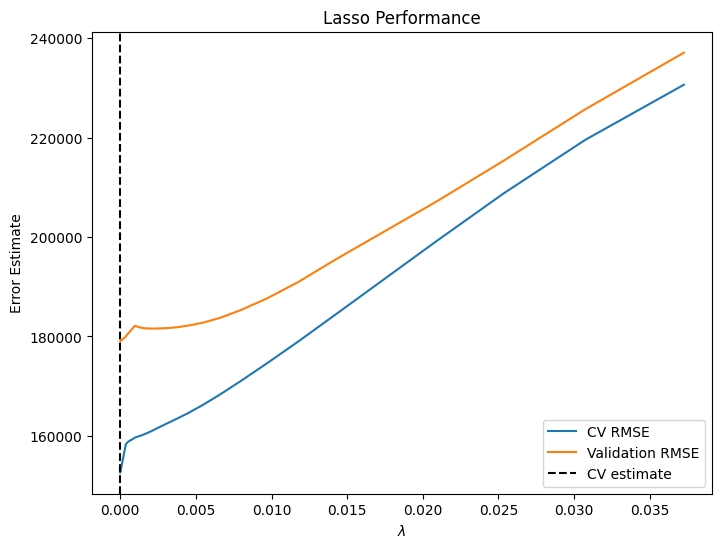

In [13]:
# Plot performance across tuning parameter values
plot_performance(cvlas, linmodel_mse, linmodel_valmse, valX, valy, title='Lasso Performance')

In [14]:
# Ridge
# Sequence of penalty parameters to try
ub = 100*np.std(trainy)*np.sqrt(2*np.log(2*p/.05))/np.sqrt(n)
lambdas = np.geomspace(start=ub/1000, stop=ub, num=50)

# Let's do cross-validation to choose a value for lambda
model = make_pipeline(StandardScaler(), Ridge())

# Cross validation. Set up parameter we are trying to optimize.
parameters = {'ridge__alpha':lambdas.ravel()}

cvridge = perform_gridsearchcv(model, parameters, scoring=scoring_log,
                               X=trainX, y=trainy, cvsplit=cvsplit, refit_metric='mse')

In [15]:
# Append results
bestmse_ridge, valmse_ridge = extract_performance_metrics(
    cvridge, linmodel_mse, linmodel_valmse, CV_benchMSE, valX, valy, val_benchMSE)
model_results = add_to_results_table(model_results, 'Ridge', bestmse_ridge, valmse_ridge, CV_benchMSE, val_benchMSE)
model_results

CV RMSE: 152385.76; CV R2: 0.828
Validation RMSE: 178939.80; Validation R2: 0.765


,Model,CV RMSE,Validation RMSE,CV R2,Validation R2
0,Mean,367810.415710,368739.847459,NaN,NaN
1,Lasso,152586.711663,178988.535261,0.827898,0.764381
2,Ridge,152385.762180,178939.803895,0.828351,0.764509


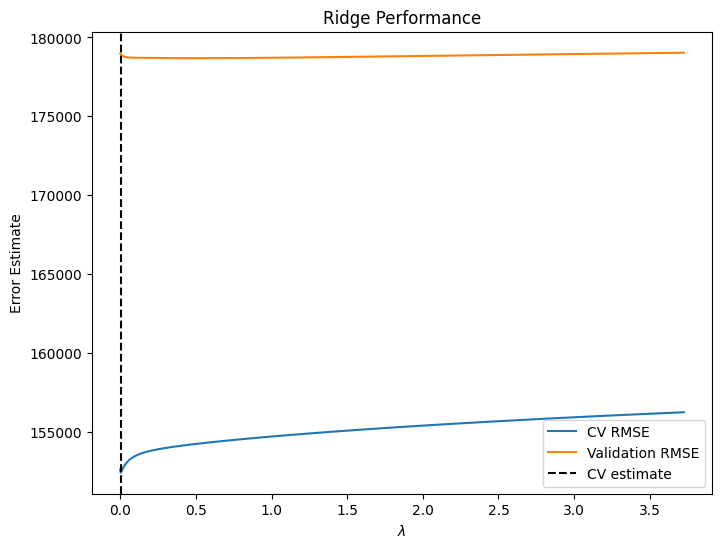

In [16]:
# Plot performance across tuning parameter values
plot_performance(cvridge, linmodel_mse, linmodel_valmse, valX, valy, title='Ridge Performance', las = False)